# Level 2 - Data Analysis Tasks
Dataset used: `Dataset  (1).csv`

This notebook contains all Level 2 tasks from the Cognifyz internship project.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Dataset  (1).csv')

# Display first 5 rows
df.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Task 1 - Restaurant Ratings

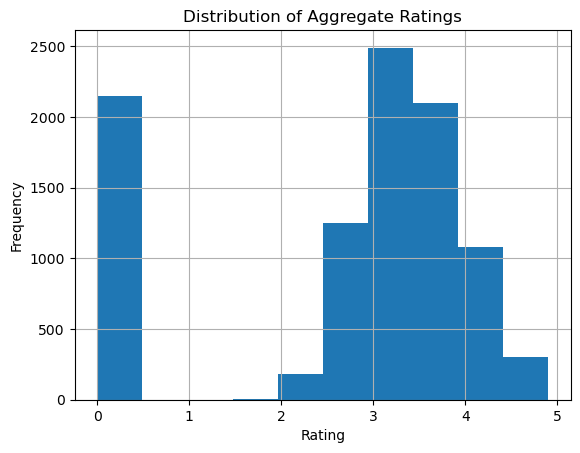

Most Common Rating Range:
Aggregate rating
(3, 4]    4388
(2, 3]    1891
(4, 5]    1114
(1, 2]      10
(0, 1]       0
Name: count, dtype: int64

Average Number of Votes:
156.909747670401


In [2]:
# Distribution of ratings
df['Aggregate rating'].hist(bins=10)
plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# Most common rating range
rating_range = pd.cut(df['Aggregate rating'], bins=[0,1,2,3,4,5])
print("Most Common Rating Range:")
print(rating_range.value_counts())

# Average votes
avg_votes = df['Votes'].mean()

print("\nAverage Number of Votes:")
print(avg_votes)


## Task 2 - Cuisine Combination

In [3]:
# Most common cuisine combinations
combo = df['Cuisines'].value_counts().head(10)

print("Most Common Cuisine Combinations:")
print(combo)

# Ratings for cuisine combinations
combo_rating = df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)

print("\nCuisine Combinations with Highest Ratings:")
print(combo_rating.head(10))


Most Common Cuisine Combinations:
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

Cuisine Combinations with Highest Ratings:
Cuisines
Italian, Deli               4.9
Hawaiian, Seafood           4.9
American, Sandwich, Tea     4.9
Continental, Indian         4.9
European, Asian, Indian     4.9
European, Contemporary      4.9
European, German            4.9
BBQ, Breakfast, Southern    4.9
American, Coffee and Tea    4.9
Sunda, Indonesian           4.9
Name: Aggregate rating, dtype: float64


## Task 3 - Geographic Analysis

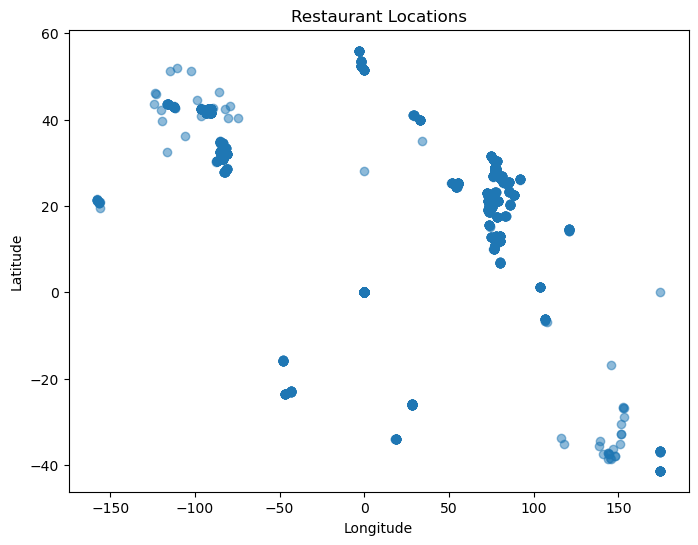

Clusters can be identified visually where many points are close together.


In [4]:
# Scatter plot of restaurant locations
plt.figure(figsize=(8,6))

plt.scatter(df['Longitude'], df['Latitude'], alpha=0.5)

plt.title('Restaurant Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

print("Clusters can be identified visually where many points are close together.")


## Task 4 - Restaurant Chains

In [5]:
# Find restaurant chains
chains = df['Restaurant Name'].value_counts()

restaurant_chains = chains[chains > 1]

print("Restaurant Chains:")
print(restaurant_chains.head(10))

# Analyze ratings and popularity
chain_analysis = df.groupby('Restaurant Name')[['Aggregate rating', 'Votes']].mean()

print("\nTop Chains by Rating and Votes:")
print(chain_analysis.loc[restaurant_chains.index].sort_values(by='Votes', ascending=False).head(10))


Restaurant Chains:
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

Top Chains by Rating and Votes:
                           Aggregate rating        Votes
Restaurant Name                                         
Truffles                           3.950000  4841.000000
Joey's Pizza                       4.250000  3903.500000
AB's - Absolute Barbecues          4.825000  3350.000000
Big Chill                          4.475000  2713.250000
Big Yellow Door                    4.266667  2503.666667
Out Of The Box                     3.850000  2450.000000
Saravana Bhavan                    4.133333  2412.666667
Olive Bistro                       4.150000  1854.000000
Talaga Sampireun                   4.900000  1838.000000
SpiceKlub                          4.300000  1825